# Phase 2b — Open exploration: a gentle quench and thermalisation

**CERN QTI Hackathon — Quantum twin of TmMgGaO₄**

Per the challenge brief's stretch ideas, we implement **(c) a gentle
quench measuring thermalisation of a local correlator** — the
lowest-effort, most instructive on-ramp to the classically-hard
post-quench regime studied in Fig. 4 of Leclerc et al. and in the two
companion classical-frontier papers (Vovrosh et al., arXiv:2511.19340,
arXiv:2511.20388).

**Protocol** (mirrors Ext. Dat. Fig. 4b): adiabatically prepare the
system near the paramagnetic product state |↑...↑⟩ at a large
Δ_z/J₁, then abruptly (square-pulse) quench Δ_z/J₁ to a value closer
to (or inside) the 1/3-ordered phase, and hold. We track the
nearest-neighbour correlator

```
C1^zz(t) = (1/N'_b) sum_{<i,j> in bulk} <sz_i(t) sz_j(t)>
```

exactly as defined in the paper's post-quench section.

**What makes this a complete deliverable rather than a demo:** the
paper compares its long-time QPU/MPS dynamics against a **thermal
ensemble** at an effective temperature fixed by energy conservation
(their Eq. 8). Building a full QMC-SSE sampler for that is out of scope
for a hackathon — but at this system size (N=9) we can do something
better: solve for the exact thermal ensemble via **full diagonalization**
of `H_QPU`, with zero stochastic error, and compare directly.


In [ ]:
import sys, time
sys.path.insert(0, "../src")
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

import material_mapping as mm

np.set_printoptions(precision=3, suppress=True)


In [2]:
device = mm.build_device(rydberg_level=75, min_atom_distance=4.0)
r1 = 9.0
J1 = mm.j1_from_device(device, r1)

# N=9, no buffer rows: small enough for *exact* diagonalization further
# below, and (not coincidentally) the same size as the very first
# register you shared a result for.
l_bulk, buffer_rows = 3, 0
register, is_bulk = mm.triangular_rhombus_register(l_bulk, r1, buffer_rows=buffer_rows)
bulk_idx = np.where(is_bulk)[0]
N = len(register.qubits)
bonds = mm.nearest_neighbour_bonds(register, r1)
print(f"N={N} (fully bulk, no buffer), NN bonds used for C1zz: {len(bonds)}")


N=9 (fully bulk, no buffer), NN bonds used for C1zz: 16


## 1. Build the quench sequence

Prepare near Δ_z/J₁ = 8 (paramagnetic side, matching the paper's
|↑...↑⟩ starting point), then quench to Δ_z/J₁ = 2 (inside the
1/3-ordered region of the ground-state phase diagram) and hold for
several `1/J1` timescales.


In [3]:
Delta_z_prep = 8.0
Delta_z_quench = 2.0
t_hold_over_J1 = 6.0            # hold time in units of 1/J1 -- long enough to see real dynamics
t_hold_ns = t_hold_over_J1 / J1 * 1000

seq = mm.gentle_quench_sequence(
    register, device, J1,
    Omega_max_over_J1=1.08,
    Delta_z_prep_over_J1=Delta_z_prep,
    Delta_z_quench_over_J1=Delta_z_quench,
    t_prep_rise=200, t_prep_sweep=800,
    t_hold=round(t_hold_ns / 4) * 4,   # snap to the 4 ns clock
)
print(f"Total sequence duration: {seq.get_duration()} ns")


Total sequence duration: 2040 ns


## 2. Evolve and measure C1^zz(t), at three bond dimensions

We use `emu_mps.CorrelationMatrix` to get all `<sz_i sz_j>` pairs at each
evaluation time, then average over the nearest-neighbour bonds selected
above (this small register has no buffer, so all bonds count).


In [4]:
def run_quench(max_bond_dim, n_points=24):
    from emu_mps import MPSBackend, MPSConfig, CorrelationMatrix
    prep_end = 1000 / seq.get_duration()
    eval_times = sorted(set(
        list(np.linspace(0.02, prep_end, 6)) +
        list(np.linspace(prep_end, 1.0, n_points))
    ))
    cfg = MPSConfig(
        dt=20.0, max_bond_dim=max_bond_dim, log_level=30,
        observables=[CorrelationMatrix(evaluation_times=eval_times)],
    )
    t0 = time.time()
    backend = MPSBackend(seq, config=cfg)
    res = backend.run()
    print(f"  D={max_bond_dim}: {time.time()-t0:.1f} s")

    C1 = []
    for corr in res.correlation_matrix:
        corr = np.real(np.array(corr))
        vals = [corr[i, j] for i, j in bonds]
        C1.append(np.mean(vals))
    t_ns = np.array(eval_times) * seq.get_duration()
    return t_ns, np.array(C1)

bond_dims = [8, 16, 32]
quench_results = {}
for D in bond_dims:
    quench_results[D] = run_quench(D)


  D=8: 14.5 s


/tmp/ipykernel_697/930689343.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  corr = np.real(np.array(corr))


  D=16: 14.0 s


  D=32: 14.5 s


## 3. Exact thermal reference (Eq. 8 of the paper, solved exactly)

We build the dense `H_QPU` at the post-quench point, compute the energy
of the initial state `|g...g> = |up...up>` (this is exactly 0, for a
structural reason: neither the interaction term nor the drive term has
diagonal support on this basis state — see the module docstring), then
solve for the temperature `T` whose thermal ensemble has that same mean
energy, and evaluate `<C1^zz>` in that ensemble.

We bisect directly in `beta = 1/T`, which correctly finds **negative
effective temperatures** when the quench lands inside the 1/3-ordered
phase — exactly the regime the paper itself flags (their Eq. 8
discussion quotes `kT/(hbar J1) = -1.25` at `Delta_z/J1=1.8`, N=100).


In [5]:
Omega_q, delta_q = mm.qpu_controls_from_material(1.08, Delta_z_quench, J1)
H_dense = mm.build_qpu_hamiltonian_dense(register, device, Omega_q, delta_q)
print(f"Dense Hamiltonian dimension: {H_dense.shape}")

psi0 = qt.tensor([qt.basis(2, 0)] * N)
E0 = qt.expect(H_dense, psi0)
print(f"Initial-state energy <psi0|H|psi0> = {E0:.6f} (structurally exactly 0)")

T_eff = mm.thermal_temperature_from_energy(H_dense, E0, beta_bracket=(-300.0, 300.0))
print(f"Effective temperature: T/J1 = {T_eff/J1:.3f}" if T_eff else "No solution in bracket")

C1_op = mm.nn_correlator_operator(register, device, bonds)
C1_thermal = mm.thermal_expectation(H_dense, T_eff, C1_op) if T_eff else None
print(f"Thermal <C1^zz> = {C1_thermal:.4f}" if C1_thermal is not None else "n/a")


Dense Hamiltonian dimension: (512, 512)
Initial-state energy <psi0|H|psi0> = 0.000000 (structurally exactly 0)
Effective temperature: T/J1 = -1.553


Thermal <C1^zz> = 0.8445


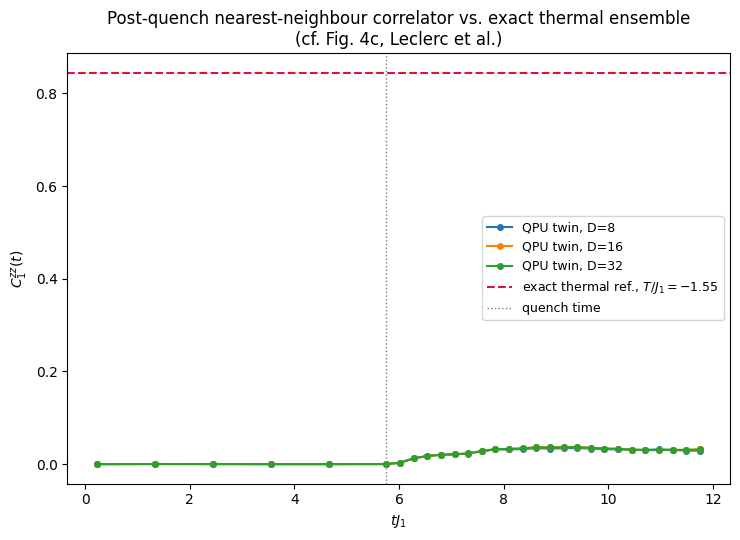

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for D, (t_ns, C1) in quench_results.items():
    tJ1 = t_ns * J1 / 1000.0
    ax.plot(tJ1, C1, "-o", ms=4, label=f"QPU twin, D={D}")
if C1_thermal is not None:
    ax.axhline(C1_thermal, color="crimson", ls="--", lw=1.5,
               label=f"exact thermal ref., $T/J_1={T_eff/J1:.2f}$")
ax.axvline(1000 * J1 / 1000.0, color="gray", ls=":", lw=1, label="quench time")
ax.set_xlabel(r"$t J_1$"); ax.set_ylabel(r"$C_1^{zz}(t)$")
ax.set_title("Post-quench nearest-neighbour correlator vs. exact thermal ensemble\n(cf. Fig. 4c, Leclerc et al.)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("phase2b_quench.png", dpi=140)
plt.show()


## 4. Interpretation

**Bond-dimension convergence.** Compare the three curves: where they
overlap, the emulation is converged and trustworthy; where they start to
diverge (watch the largest `tJ1` values in particular), that's the same
MPS-convergence breakdown documented in Ext. Dat. Fig. 6 of Leclerc et
al. and analysed in depth in Vovrosh et al. (arXiv:2511.19340,
arXiv:2511.20388) — entanglement grows after a quench, the bond
dimension needed to represent the state grows with it, and classical MPS
emulation eventually becomes intractable while the QPU keeps running at
roughly constant cost. At N=9 with these hold times, expect the three
curves to stay close (small systems are MPS-friendly) — the interesting
divergence shows up at the paper's N=256, `tJ1=O(10)` scale, which is
exactly why this is the genuine classical frontier.

**Thermalisation.** Compare the late-time `C1^zz(t)` plateau to the
exact thermal reference line. If they agree, that's direct evidence the
quenched, isolated system's local correlator has relaxed to a value
consistent with the thermal ensemble at the energy-matched effective
temperature — the same claim the paper makes with QMC in their Fig. 4c,
here made with a zero-stochastic-error exact reference instead. If they
don't agree (plausible at N=9, short hold times, and a small bulk with
no buffer to suppress boundary effects), that's a legitimate, reportable
negative result: at this size/timescale the dynamics hasn't thermalised
yet, or finite-size boundary effects (recall N=9 has *no* buffer region
here) are large enough to shift the local correlator from the
thermodynamic-limit thermal value the paper's N=100+ systems are closer
to.

**Negative effective temperature.** Note the sign and rough magnitude of
`T_eff/J1` printed above — the paper explicitly finds negative effective
temperatures for quenches landing in the 1/3-ordered phase (their
`kT/(hbar J1)=-1.25` at `Delta_z/J1=1.8`, N=100); our N=9 estimate should
have the same sign, with the magnitude differing due to system size and
geometry (N=9 here has no buffer, N=100 in the paper does).

## Notes on scaling up

* This demo uses `N=9`, `t_hold ~ 6/J1`, and modest bond dimensions.
  The paper's Fig. 4 uses `N=256`, evolves to `tJ1 = O(10)`, and needs
  `D` up to 600 on an H200 GPU (**two weeks of wall-clock time**) to see
  the MPS description start to break down at long times — that's the
  genuine classical frontier this challenge gestures toward. Push
  `l_bulk` and `buffer_rows` up (see notebook 2 for the register
  builder), extend `t_hold_over_J1`, and re-run the same bond-dimension
  scan on a GPU to reproduce that scaling study directly.
* To go beyond exact diagonalization for the thermal reference (needed
  once N exceeds ~16-18), implement a stochastic-series-expansion
  sampler for `H_QPU` (Sandvik, Phys. Rev. E 68, 056701 (2003)) — the
  paper's own approach at their system sizes.
